# [title] One-state Model: a posterior network trained with BayesFlow

**Question.** Can a neural network, trained once on simulated Sittings of the one-state
Model, give a trustworthy posterior of the Model's four parameters for a new Sitting, at
its full length, without downsampling and without padding?

**Scope.** Step C3b of [issue #12](https://github.com/opherdonchin/MotorAdpatationSBI/issues/12).
Background: the wiki pages
[Concept-amortized-inference](https://github.com/opherdonchin/MotorAdpatationSBI/wiki/Concept-amortized-inference)
(what is trained, and how it is checked),
[Concept-summary-networks](https://github.com/opherdonchin/MotorAdpatationSBI/wiki/Concept-summary-networks)
(how the network reads a Sitting) and
[Concept-bayesflow-loss-functions](https://github.com/opherdonchin/MotorAdpatationSBI/wiki/Concept-bayesflow-loss-functions)
(what the loss is). Why this summary network and this way of batching:
[decision 0007](../../docs/decisions/0007-summary-network-for-sittings.md). The Model,
Prior and Schedule Design: [docs/models/one_state.md](../../docs/models/one_state.md).
Terms: [glossary](../../docs/glossary.md).

**What is built.** An Inference Engine: a summary network (convolution, then
recurrence) that reads every Trial of a Sitting ($p_t$, $v_t$, $y_t$), followed by a
flow-matching inference network that turns its 12 summary numbers into draws from the
posterior of $A$, $B$, $\sigma_\eta$ and $\sigma_\varepsilon$. It is trained on Sittings
simulated as they are needed, with the Prior and Schedule Design of decision 0005, and
checked on a saved test Experiment.

**The one rule that makes this work without padding:** all Sittings in a training batch
share one Schedule, so they have one length. Different batches have different Schedules
and lengths. The trained network takes a Sitting of any length as it is.

**Checks:**

1. *Training converged:* the loss on held-out Sittings has flattened and has not pulled
   away from the training loss.
2. *Calibration* (the Check that decides whether to trust the Engine): over the test
   Sittings, the true value of each parameter falls in the posterior's intervals as
   often as it should.
3. *Recovery and contraction* (reported, not pass or fail): how close the posterior's
   centre is to the true value, and how much narrower the posterior is than the Prior.
4. *Sitting length:* Checks 2 and 3 separately for the shorter and the longer test
   Sittings.

In [1]:
# [imports]
import json
import pathlib
import subprocess

import bayesflow as bf
import keras
import numpy as np
import pandas as pd
from scipy import special, stats

from designs import visuomotor_adaptation_experiment as des
from models import one_state as mdl
from motor_sbi import experiments

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


INFO:bayesflow:Using backend 'jax'


/home/opher/Repositories/MotorAdpatationSBI/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [config] Root seed, provenance, Prior and Schedule Design, sizes, networks, training
root_seed = 112907950985685676175328411057333210321  # secrets.randbits(128)

# Provenance: the repository's top folder, the commit that produced the outputs (with
# -dirty if there were uncommitted changes), and where this notebook's outputs go.
REPO = pathlib.Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())
GIT_COMMIT = subprocess.check_output(["git", "describe", "--always", "--dirty"], text=True).strip()
TEST_DIR = REPO / "data" / "simulated" / "one_state_random_blocks_test"
OUT_DIR = REPO / "outputs" / "one_state" / "engines" / "posterior_random_blocks"

# The Prior and Schedule Design of decision 0005, from their stated 95% ranges.
z95 = stats.norm.ppf(0.975)
range_a, range_b = (0.75, 0.999), (0.01, 0.5)
range_sigma_epsilon, range_ratio, range_block_len = (1 / 15, 1 / 3), (1 / 15, 1 / 5), (10, 250)
prior = {
    "mu_logit_A": special.logit(range_a).mean(), "sigma_logit_A": np.ptp(special.logit(range_a)) / (2 * z95),
    "mu_logit_B": special.logit(range_b).mean(), "sigma_logit_B": np.ptp(special.logit(range_b)) / (2 * z95),
    "mu_log_sigma_epsilon": np.log(range_sigma_epsilon).mean(),
    "sigma_log_sigma_epsilon": np.ptp(np.log(range_sigma_epsilon)) / (2 * z95),
    "mu_log_ratio": np.log(range_ratio).mean(), "sigma_log_ratio": np.ptp(np.log(range_ratio)) / (2 * z95),
}
schedule_design = {
    "n_blocks_min": 5, "n_blocks_max": 16,
    "mu_log_block_len": np.log(range_block_len).mean(),
    "sigma_log_block_len": np.ptp(np.log(range_block_len)) / (2 * z95),
    "trial_type_concentration": 3.0,
}


# Training: Sittings are simulated as they are needed and never reused.
batch_size = 32  # Sittings per batch, all on one Schedule (BayesFlow's default batch size)
batches_per_epoch = 300
epochs = 100  # with batches_per_epoch: 960,000 Sittings in all
# Each new Sitting length makes JAX compile the training step again (about 5 s). Cutting
# every training Schedule down to a multiple of length_step Trials (at most 24 Trials
# lost, from the end) keeps the number of distinct lengths below about a hundred.
length_step = 25
n_validation = 300  # held-out Sittings on one Schedule, for the loss after each epoch

# Test Experiment: Schedules of the Schedule Design as they come (no cutting), several
# Sittings on each. 300 Sittings in all, as agreed for the Checks.
n_test_schedules = 30
n_sittings_per_test_schedule = 10

# Networks at BayesFlow's "Base" size, the size its guidance says to start with.
summary_dim = 12  # 3 summary numbers per parameter (BayesFlow's starting heuristic)
conv_filters = (32, 64)  # two convolution layers, each over a window of conv_window Trials
conv_window = 3
recurrent_units = 128  # size of the state the recurrent layers carry from Trial to Trial
flow_widths = (256, 256, 256, 256)
flow_time_embedding_dim = 32

n_posterior_draws = 1000  # per test Sitting, for the Checks (BayesFlow's default)

In [3]:
# [rng] One stream for training and validation batches, one for the test Experiment; a seed for Keras
rng = np.random.default_rng(root_seed)
rng_batches, rng_test = rng.spawn(2)
keras.utils.set_random_seed(int(rng.integers(2**31)))
series_vars = mdl.TASK.CONDITION_VARS + mdl.TASK.OBSERVATION_VARS

## [simulator] Batches of Sittings on one Schedule

BayesFlow asks for training data one batch at a time, through a function that takes the
number of Sittings wanted and returns arrays. `sample_batch` is that function. It is our
own `simulate_experiment`, asked for one Schedule with `n` Sittings on it (each with its
own parameter values from the Prior), followed by two rearrangements: the Sittings are
stacked into arrays of shape (Sittings, Trials), and the Trials beyond a multiple of
`length_step` are cut off. A Sitting with its last few Trials removed is still a Sitting
of the Model, on the shortened Schedule, so nothing about the Model is approximated.

BayesFlow gives this function no random generator, so it uses the notebook's
`rng_batches` stream.

In [4]:
# [sample-batch] One Schedule, n Sittings on it, as arrays (n, Trials); parameters as (n, 1)
def sample_batch(batch_shape):
    '''Simulate one batch for BayesFlow: Sittings that share one Schedule.

    Parameters
    ----------
    batch_shape : tuple of int, shape (1,)
        ``(n,)``, the number of Sittings wanted; this is how BayesFlow asks.

    Returns
    -------
    batch : dict of numpy.ndarray, float32
        One array of shape (n, T) per Condition and Observation of the Task (``p``,
        ``v``, ``y``), and one of shape (n, 1) per parameter of the Model. T is the
        length of the Schedule drawn for this batch, cut down to a multiple of
        `length_step` (left as it is if shorter than `length_step`).

    Uses and advances the notebook's `rng_batches`; reads `prior`, `schedule_design` and
    `length_step` from the config cell.
    '''
    n = batch_shape[0]
    sittings, ground_truth = experiments.simulate_experiment(
        rng_batches, mdl, prior, des.sample_schedule, schedule_design, n, n_sittings_per_schedule=n
    )
    n_trials = len(sittings[0]["y"])
    if n_trials >= length_step:
        n_trials -= n_trials % length_step
    batch = {name: np.stack([s[name][:n_trials] for s in sittings]).astype("float32") for name in series_vars}
    for name in mdl.PARAMETERS:
        batch[name] = np.array([[truth[name]] for truth in ground_truth], dtype="float32")
    return batch


simulator = bf.make_simulator(sample_batch, is_batched=True)
validation = simulator.sample(n_validation)
pd.Series({name: values.shape for name, values in validation.items()}, name="shapes in the validation batch")

p                (300, 425)
v                (300, 425)
y                (300, 425)
A                  (300, 1)
B                  (300, 1)
sigma_eta          (300, 1)
sigma_epsilon      (300, 1)
Name: shapes in the validation batch, dtype: object

## [engine] The Inference Engine

**The adapter** says which array goes where. `p`, `v` and `y` together are what the
summary network reads, one row of three numbers per Trial. The four parameters are what
the inference network learns the distribution of; `constrain` moves them to unbounded
scales first ($A$ and $B$ by the logit, the two noise sizes by a log-like transform), so
the network can never propose a value outside a parameter's domain.

**The summary network** is BayesFlow's `TimeSeriesNetwork`: two convolution layers compute
features of each Trial and its neighbours (5 Trials in all), and recurrent layers then
read those features Trial by Trial in both directions, carrying a state of 128 numbers.
**The inference network** is flow matching, BayesFlow's recommended default.

Only the parameters are standardized by BayesFlow; the Sittings are already in units of
the perturbation size.

In [5]:
# [adapter] Route the arrays: p, v, y to the summary network; the parameters to the inference network
adapter = (
    bf.Adapter()
    .as_time_series(list(series_vars))
    .constrain(["A", "B"], lower=0, upper=1)
    .constrain(["sigma_eta", "sigma_epsilon"], lower=0)
    .concatenate(list(series_vars), into="summary_variables")
    .concatenate(list(mdl.PARAMETERS), into="inference_variables")
)

In [6]:
# [workflow] The two networks and the BayesFlow workflow that trains and saves them
OUT_DIR.mkdir(parents=True, exist_ok=True)
workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    summary_network=bf.networks.TimeSeriesNetwork(
        summary_dim=summary_dim, filters=conv_filters, kernel_sizes=conv_window, recurrent_dim=recurrent_units
    ),
    inference_network=bf.networks.FlowMatching(
        subnet_kwargs={"widths": flow_widths, "time_embedding_dim": flow_time_embedding_dim}
    ),
    standardize="inference_variables",
    checkpoint_filepath=str(OUT_DIR),
    checkpoint_name="engine",
)

## [train] Training

An "epoch" here is just `batches_per_epoch` fresh batches; no Sitting is ever seen twice.
After each epoch the Engine is saved to `engine.keras` and the loss is computed on the
validation batch. The first batches at each new Sitting length are slow, because JAX
compiles the training step for that length.

In [7]:
# [fit] Train, then save the loss history and the record of what produced the Engine
history = workflow.fit_online(
    epochs=epochs, num_batches_per_epoch=batches_per_epoch, batch_size=batch_size,
    validation_data=validation, verbose=2,
)
_ = (OUT_DIR / "history.json").write_text(json.dumps(history.history))
_ = (OUT_DIR / "record.json").write_text(json.dumps({
    "model": mdl.__name__, "schedule_generator": f"{des.__name__}.sample_schedule",
    "prior": prior, "schedule_design": schedule_design,
    "summary_network": "TimeSeriesNetwork", "summary_dim": summary_dim, "conv_filters": conv_filters,
    "conv_window": conv_window, "recurrent_units": recurrent_units,
    "inference_network": "FlowMatching", "flow_widths": flow_widths,
    "epochs": epochs, "batches_per_epoch": batches_per_epoch, "batch_size": batch_size,
    "length_step": length_step, "root_seed": str(root_seed), "git_commit": GIT_COMMIT,
}, indent=2))

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.


INFO:bayesflow:Building on a test batch.


Epoch 1/100


300/300 - 297s - 988ms/step - loss: 1.7126 - val_loss: 1.5084


Epoch 2/100


...

300/300 - 38s - 125ms/step - loss: 0.3023 - val_loss: 0.2853


Epoch 100/100


300/300 - 36s - 119ms/step - loss: 0.3050 - val_loss: 0.3070


INFO:bayesflow:Training completed in 1.18 hours.


INFO:bayesflow:Training is now finished.
You can find the trained approximator at '/home/opher/Repositories/MotorAdpatationSBI/outputs/one_state/engines/posterior_random_blocks/engine.keras'.
To restore it:
Via the workflow: workflow.load_approximator()
Standalone: approximator = keras.saving.load_model("/home/opher/Repositories/MotorAdpatationSBI/outputs/one_state/engines/posterior_random_blocks/engine.keras")


## [check-1] Check 1: training converged

The loss is a squared error on a velocity, not a log probability, so it does not go to
zero. What to look for: both curves flat at the end, and the validation loss not above
the training loss. The validation batch is on a single Schedule, so its level need not
equal the training loss, which averages over Schedules; its trend is what matters.

training loss, mean of last 10 epochs            0.307
training loss, mean of the 10 epochs before      0.312
validation loss, mean of last 10 epochs          0.304
validation loss, mean of the 10 epochs before    0.324
dtype: float64

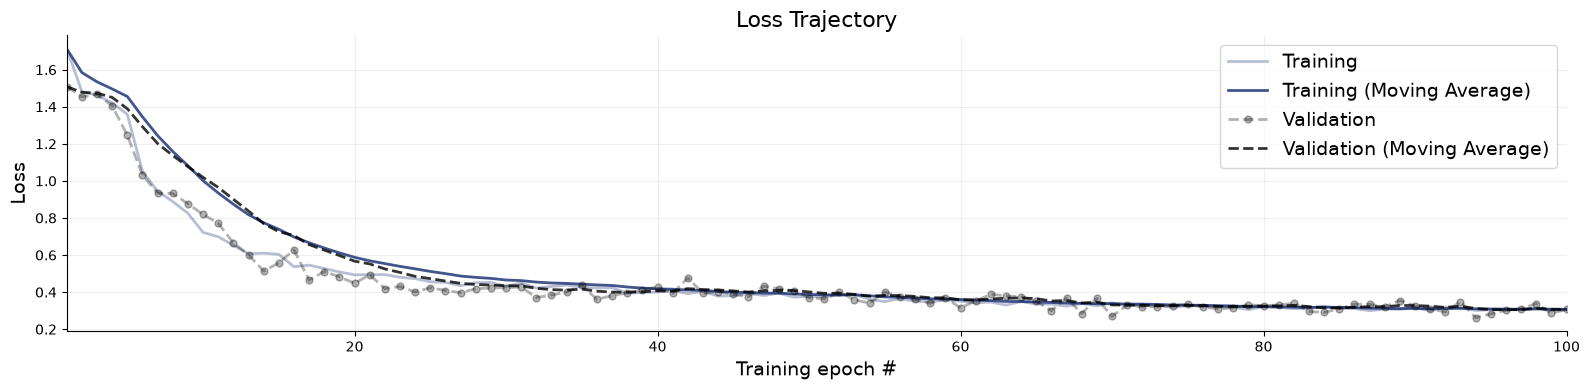

In [8]:
# [check-training] Training and validation loss per epoch
loss = pd.DataFrame(history.history)[["loss", "val_loss"]]
fig = bf.diagnostics.plots.loss(history)
pd.Series({
    "training loss, mean of last 10 epochs": round(loss["loss"].tail(10).mean(), 3),
    "training loss, mean of the 10 epochs before": round(loss["loss"].iloc[-20:-10].mean(), 3),
    "validation loss, mean of last 10 epochs": round(loss["val_loss"].tail(10).mean(), 3),
    "validation loss, mean of the 10 epochs before": round(loss["val_loss"].iloc[-20:-10].mean(), 3),
})

## [test] The test Experiment

A Simulated Experiment saved like any other, with its Ground Truth apart: Schedules
straight from the Schedule Design (their lengths are not cut to the training grid, so
most are lengths the network never trained on), and several Sittings on each Schedule.
The Engine is given each Sitting as it is.

In [9]:
# [simulate-test] Simulate and save the test Experiment; load it back as an Analysis would
n_test = n_test_schedules * n_sittings_per_test_schedule
sittings, ground_truth = experiments.simulate_experiment(
    rng_test, mdl, prior, des.sample_schedule, schedule_design, n_test,
    n_sittings_per_schedule=n_sittings_per_test_schedule,
)
experiments.save_experiment(TEST_DIR, sittings, ground_truth, {
    "model": mdl.__name__, "schedule_generator": f"{des.__name__}.sample_schedule",
    "prior": prior, "schedule_design": schedule_design,
    "n_sittings": n_test, "n_sittings_per_schedule": n_sittings_per_test_schedule,
    "root_seed": str(root_seed), "git_commit": GIT_COMMIT,
})
del sittings, ground_truth

test_sittings = experiments.load_sittings(TEST_DIR)
truth, _ = experiments.load_ground_truth(TEST_DIR)
test_truth = {name: truth[name][:, None].astype("float32") for name in mdl.PARAMETERS}
test_lengths = np.array([len(s["y"]) for s in test_sittings])
pd.Series(test_lengths[::n_sittings_per_test_schedule]).describe().round(0).rename("Trials per test Schedule")

count      30.0
mean      857.0
std       389.0
min       270.0
25%       522.0
50%       858.0
75%      1055.0
max      1771.0
Name: Trials per test Schedule, dtype: float64

## [check-2] Checks 2 and 3: calibration, recovery and contraction on the test Experiment

For each test Sitting the Engine draws from its posterior; the same draws serve all the
Checks. Sittings on the same Schedule are given to the Engine together, as one array.
The figures and the table are BayesFlow's own diagnostics.

- **Calibration** (`calibration_ecdf`, and *Calibration Error* in the table): for each
  parameter, where the true value ranks among the posterior draws. If the posterior is
  honest, the ranks are uniform and the curve stays inside the grey band.
- **Recovery** (`recovery`, and *NRMSE*): posterior median against true value.
- **Contraction** (`z_score_contraction`, and *Posterior Contraction*): 1 minus the
  posterior's variance over the Prior's; 0 means the Sitting taught nothing about the
  parameter, 1 means it pinned it down.

In [10]:
# [sample-test] Posterior draws for every test Sitting, one Schedule at a time
draws_by_schedule = []
for first in range(0, n_test, n_sittings_per_test_schedule):
    group = test_sittings[first : first + n_sittings_per_test_schedule]
    conditions = {name: np.stack([s[name] for s in group]).astype("float32") for name in series_vars}
    draws_by_schedule.append(workflow.sample(conditions=conditions, num_samples=n_posterior_draws))
draws = {name: np.concatenate([d[name] for d in draws_by_schedule]) for name in mdl.PARAMETERS}

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing: 100%|██████████| 1/1 [00:03<00:00,  3.13s/batch]

Summarizing: 100%|██████████| 1/1 [00:03<00:00,  3.13s/batch]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling: 100%|██████████| 1/1 [00:13<00:00, 13.27s/batch]

...

Summarizing: 100%|██████████| 1/1 [00:02<00:00,  2.58s/batch]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling: 100%|██████████| 1/1 [00:07<00:00,  7.01s/batch]

Sampling: 100%|██████████| 1/1 [00:07<00:00,  7.01s/batch]


INFO:bayesflow:Sampling completed in 9.62 seconds.


,A,B,sigma_eta,sigma_epsilon
NRMSE,0.062,0.088,0.428,0.083
Log Gamma,0.082,-3.166,2.730,1.388
Calibration Error,0.010,0.051,0.012,0.011
Posterior Contraction,0.997,0.993,0.844,0.994


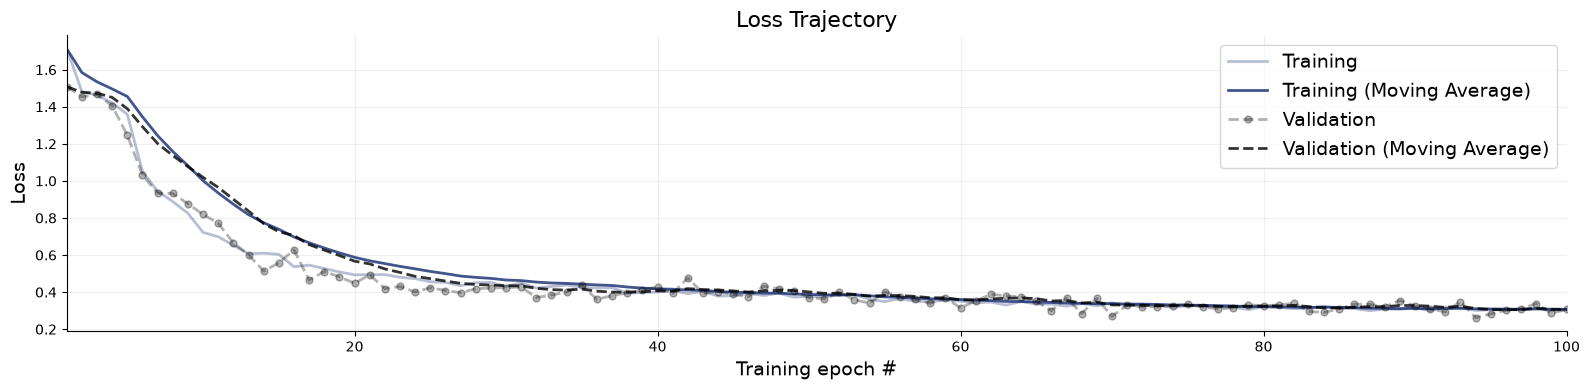

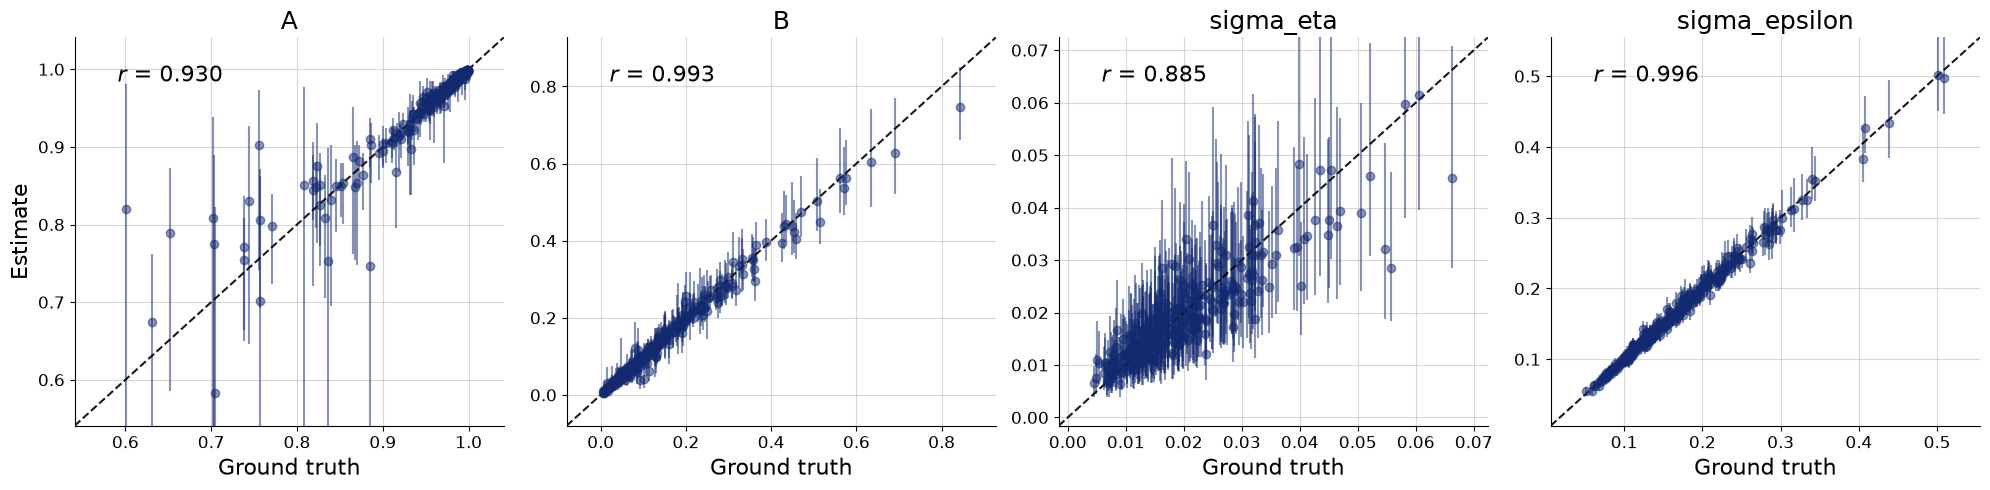

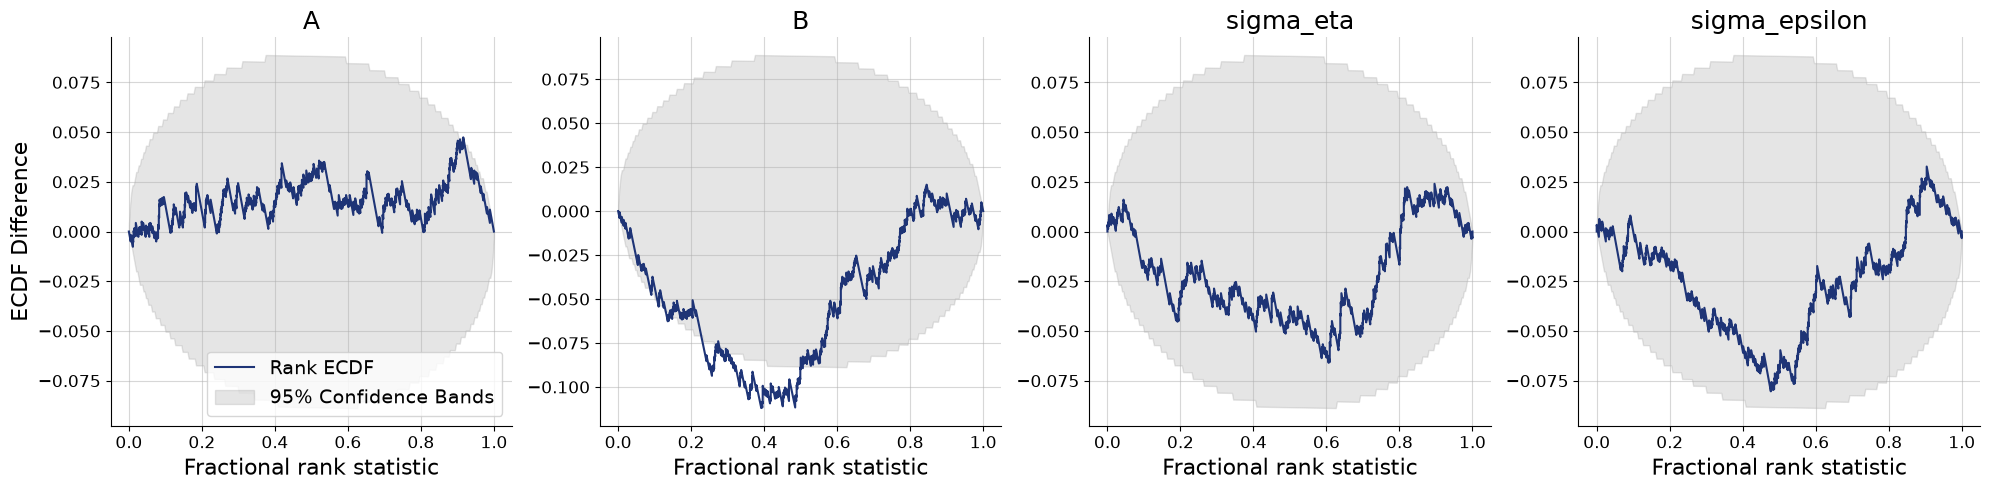

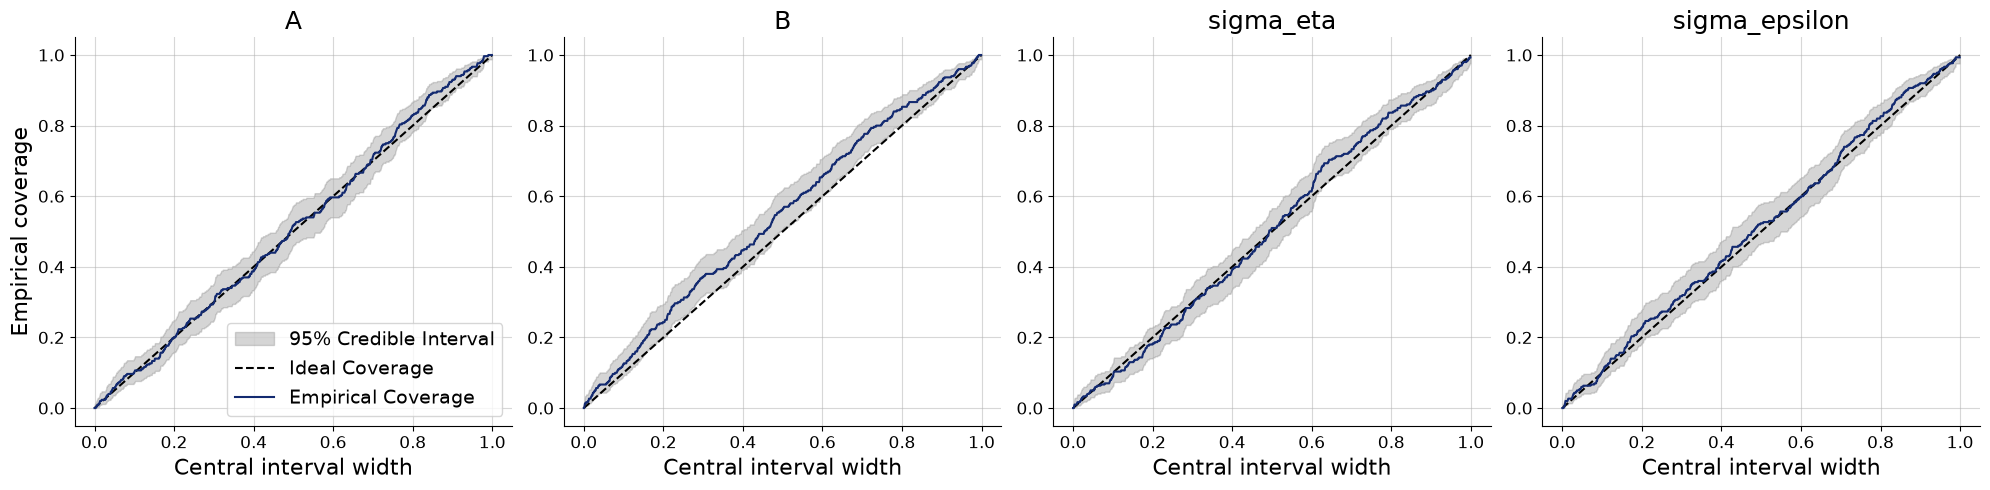

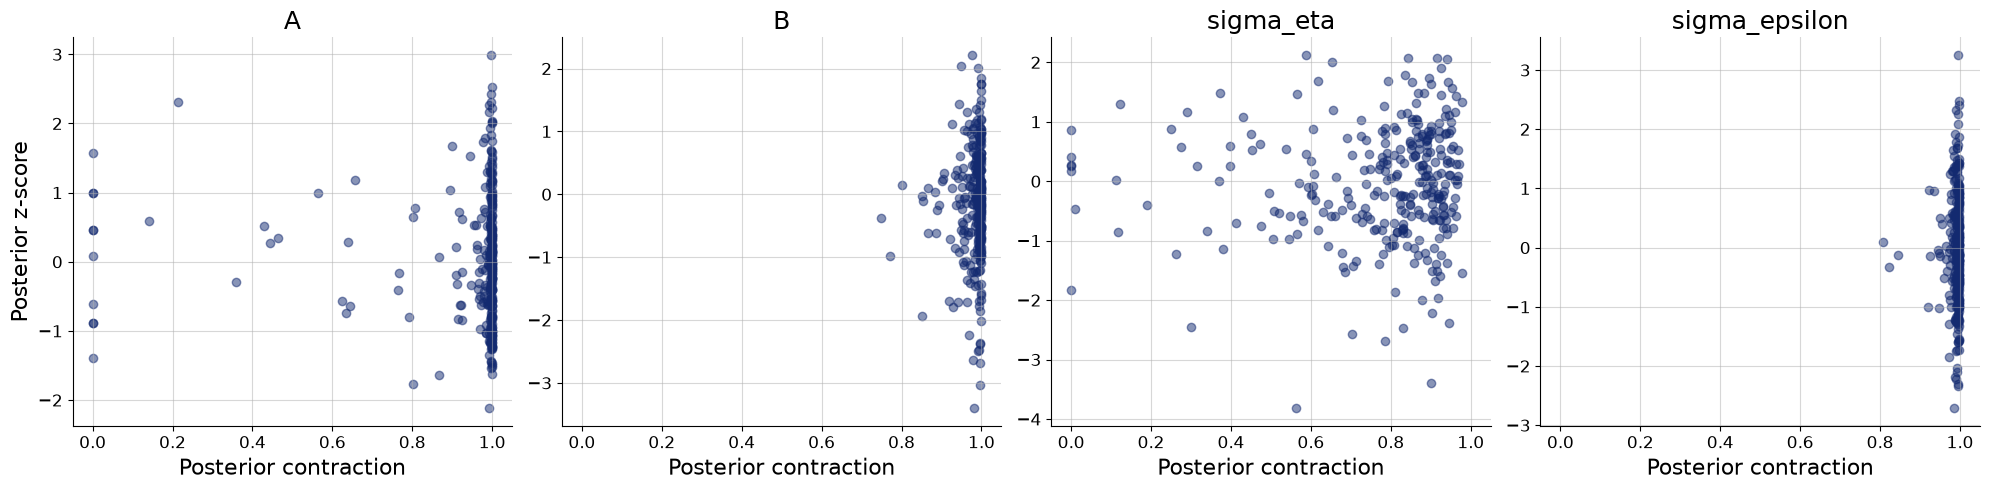

In [11]:
# [check-diagnostics] BayesFlow's default diagnostics: figures and table, both saved
figures = workflow.plot_default_diagnostics(test_data=test_truth, samples=draws)
for name, fig in figures.items():
    fig.savefig(OUT_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
metrics = workflow.compute_default_diagnostics(test_data=test_truth, samples=draws, as_data_frame=True)
metrics.to_csv(OUT_DIR / "metrics.csv")
metrics.round(3)

## [check-4] Check 4: does Sitting length matter?

The same table for the test Sittings on the shorter and on the longer Schedules. Longer
Sittings hold more information, so better recovery and more contraction are expected
there. What would be a warning is *calibration* that differs between the two: it would
mean the Engine handles some lengths badly.

In [12]:
# [check-length] Default diagnostics for the Sittings on the shorter and on the longer Schedules
is_long = test_lengths >= np.median(test_lengths)
halves = {"shorter": ~is_long, "longer": is_long}
by_length = pd.concat({
    f"{label} ({test_lengths[rows].min()} to {test_lengths[rows].max()} Trials, {rows.sum()} Sittings)":
        workflow.compute_default_diagnostics(
            test_data={name: values[rows] for name, values in test_truth.items()},
            samples={name: values[rows] for name, values in draws.items()},
            as_data_frame=True,
        )
    for label, rows in halves.items()
})
by_length.round(3)

A      B  \
shorter (270 to 853 Trials, 150 Sittings) NRMSE                  0.066  0.101   
                                          Log Gamma              2.955 -1.046   
                                          Calibration Error      0.034  0.038   
                                          Posterior Contraction  0.997  0.990   
longer (864 to 1771 Trials, 150 Sittings) NRMSE                  0.058  0.076   
                                          Log Gamma             -0.292  1.288   
                                          Calibration Error      0.049  0.052   
                                          Posterior Contraction  0.997  0.995   

                                                                 sigma_eta  \
shorter (270 to 853 Trials, 150 Sittings) NRMSE                      0.467   
                                          Log Gamma                  2.972   
                                          Calibration Error          0.028   
                                          Posterior Contraction      0.808   
longer (864 to 1771 Trials, 150 Sittings) NRMSE                      0.392   
                                          Log Gamma                  1.745   
                                          Calibration Error          0.020   
                                          Posterior Contraction      0.876   

                                                                 sigma_epsilon  
shorter (270 to 853 Trials, 150 Sittings) NRMSE                          0.102  
                                          Log Gamma                      1.682  
                                          Calibration Error              0.045  
                                          Posterior Contraction          0.992  
longer (864 to 1771 Trials, 150 Sittings) NRMSE                          0.062  
                                          Log Gamma                     -1.105  
                                          Calibration Error              0.076  
                                          Posterior Contraction          0.996

## [results] What this shows

Run of 2026-10-10 at commit `1841a5c`: 100 epochs of 300 batches (960,000 Sittings),
1.18 hours on the 8 GB graphics card. Test Experiment: 30 Schedules of 270 to 1,771
Trials, 10 Sittings each.

**Check 1, training converged: mostly.** Both losses fall from about 1.7 to about 0.31.
The last 10 epochs average 0.307 (training) and 0.304 (validation), against 0.312 and
0.324 for the 10 before: nearly flat, still creeping down. No overfitting, as expected
when no Sitting is seen twice.

**Check 2, calibration: three parameters pass, $B$ does not quite.** For $A$,
$\sigma_\eta$ and $\sigma_\epsilon$ the rank curves stay inside the 95% band and the
calibration error is about 0.01. For $B$ the curve leaves the band (largest gap 0.11),
the calibration error is 0.05, and Log Gamma is $-3.2$ (below 0 means uniform ranks are
rejected at the 5% level). The direction: the posterior of $B$ sits slightly too low and
is slightly too wide.

**Check 3, recovery and contraction: good.** Correlation of posterior median with the
true value: $A$ 0.93, $B$ 0.99, $\sigma_\eta$ 0.89, $\sigma_\epsilon$ 1.00. Contraction:
0.997, 0.993, 0.84, 0.994. $\sigma_\eta$ is the least well determined, as expected for
the smaller of two noises. $A$ is recovered tightly near 1 and loosely below about 0.85,
where the Prior puts few Sittings.

**Check 4, Sitting length: no clear effect on calibration.** Longer Sittings recover
better (every error smaller) and contract more for $\sigma_\eta$ (0.88 against 0.81).
Calibration errors are 0.02 to 0.08 in both halves; each half has only 150 Sittings, so
these are noisier than the full table. Log Gamma is below 0 for $B$ in the shorter half
and for $A$ and $\sigma_\epsilon$ in the longer half, all mildly. Test Schedules are not
on the training grid of lengths, so the Engine handles lengths it never trained on.

**In short.** The Engine recovers all four parameters from full-length Sittings, with no
downsampling and no padding. It is not yet a posterior to trust without qualification:
$B$ is measurably miscalibrated, and none of this has been compared with an exact
posterior (stage 2 of issue #12).
